# Unidad 4 · Modelamiento cuantitativo: regresión lineal

**Qué vas a aprender**
- Ajustar una regresión lineal **simple** y una **múltiple**, e interpretar sus coeficientes.
- Revisar los supuestos: residuos, heterocedasticidad, colas gruesas, y usar errores típicos robustos.
- Reconocer la **multicolinealidad** y medirla con el VIF.
- Evaluar un modelo **fuera de la muestra**, que es la única evaluación que cuenta.

**Qué tiene que ver con la app.** En la pantalla **Hoy**, el piloto muestra qué parte del **riesgo**
aporta cada moneda: una puede ser el 30 % del dinero y el 50 % del riesgo. Esa cuenta es una
regresión disfrazada: el peso en riesgo es el peso en dinero por la **beta** de la moneda frente a tu
cartera. Al final la reproduces.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

precios = cierres().dropna()                       # días comunes a BTC, ETH y SOL
ret = np.log(precios).diff().dropna()              # rendimientos logarítmicos diarios
print(ret.shape[0], "días, del", ret.index[0].date(), "al", ret.index[-1].date())
ret.corr().round(3)

2237 días, del 2020-08-12 al 2026-09-26


,BTC,ETH,SOL
BTC,1.000,0.815,0.589
ETH,0.815,1.000,0.658
SOL,0.589,0.658,1.000


## 1. Regresión simple: ¿cuánto se mueve ETH cuando se mueve BTC?

$$r_{ETH,t} = \alpha + \beta\, r_{BTC,t} + \varepsilon_t$$

- $\beta$ (**beta**): cuánto se mueve ETH, de media, cuando BTC se mueve un 1 %.
- $\alpha$: el rendimiento de ETH los días en que BTC no se mueve.
- $\varepsilon$: lo que BTC no explica.

`smf.ols` usa la notación de fórmulas de R: `"ETH ~ BTC"` se lee "ETH explicado por BTC".

In [3]:
m1 = smf.ols("ETH ~ BTC", data=ret).fit()
print(m1.summary().tables[1])
print(f"R² = {m1.rsquared:.3f}   n = {int(m1.nobs)}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0001      0.000     -0.229      0.819      -0.001       0.001
BTC            1.1068      0.017     66.515      0.000       1.074       1.139
R² = 0.664   n = 2237


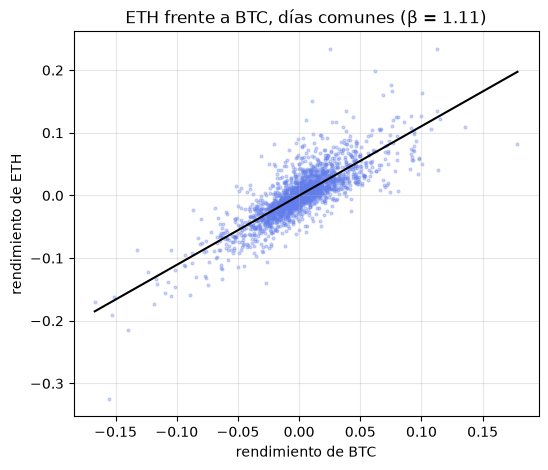

In [4]:
x = np.linspace(ret["BTC"].min(), ret["BTC"].max(), 2)
plt.figure(figsize=(6, 5))
plt.scatter(ret["BTC"], ret["ETH"], s=4, alpha=0.3, color=COLORES["ETH"])
plt.plot(x, m1.params["Intercept"] + m1.params["BTC"] * x, color="black")
plt.xlabel("rendimiento de BTC"); plt.ylabel("rendimiento de ETH")
plt.title(f"ETH frente a BTC, días comunes (β = {m1.params['BTC']:.2f})"); plt.show()

**Cómo se lee:**
- **β ≈ 1,1**: un día en que BTC sube un 1 %, ETH sube de media un 1,1 %. ETH amplifica a BTC.
- **α** es prácticamente cero y su *p-valor* es alto: no hay un rendimiento "extra" de ETH
  independiente de BTC que se pueda distinguir del azar.
- **R² ≈ 0,65**: BTC explica dos tercios de lo que se mueve ETH cada día. El tercio restante es
  propio de ETH.
- El *p-valor* de β es 0 (redondeado): con más de 2000 días, una relación así no puede ser casualidad.

## 2. Los supuestos, y errores típicos robustos

Los *p-valores* de la tabla suponen que los errores tienen siempre la misma varianza
(**homocedasticidad**) y, para muestras pequeñas, que son normales. En cripto no se cumple ninguna de
las dos cosas. Dos pruebas:
- **Breusch-Pagan**: ¿la varianza del error depende de las variables? (p pequeño = sí).
- **Gráfico de residuos**: la nube debería tener el mismo ancho en todo el eje.

Breusch-Pagan: estadístico 9.6, p-valor 0.0019
Curtosis de los residuos: 9.6 (una normal tiene 3)


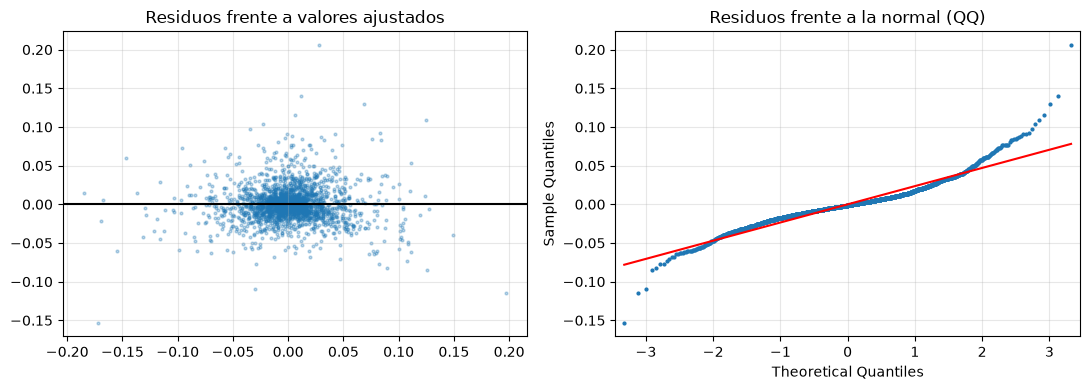

In [5]:
lm, p_lm, _, _ = het_breuschpagan(m1.resid, m1.model.exog)
print(f"Breusch-Pagan: estadístico {lm:.1f}, p-valor {p_lm:.2g}")
curtosis = ((m1.resid - m1.resid.mean()) ** 4).mean() / m1.resid.var(ddof=0) ** 2
print(f"Curtosis de los residuos: {curtosis:.1f} (una normal tiene 3)")

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].scatter(m1.fittedvalues, m1.resid, s=4, alpha=0.3); ejes[0].axhline(0, color="black")
ejes[0].set_title("Residuos frente a valores ajustados")
sm.qqplot(m1.resid, line="s", ax=ejes[1], markersize=2); ejes[1].set_title("Residuos frente a la normal (QQ)")
plt.tight_layout(); plt.show()

Hay heterocedasticidad (los días agitados tienen errores más grandes) y colas mucho más gruesas que
la normal (los puntos del QQ se escapan de la recta en los extremos). La β sigue siendo válida, pero
su error típico no. La solución estándar son los **errores típicos robustos** (HC1, de White): se
calculan sin suponer varianza constante.

In [6]:
m1r = smf.ols("ETH ~ BTC", data=ret).fit(cov_type="HC1")
pd.DataFrame({"coef": m1.params, "ee_clasico": m1.bse, "ee_robusto": m1r.bse}).round(5)

,coef,ee_clasico,ee_robusto
Intercept,-0.00011,0.00050,0.00050
BTC,1.10683,0.01664,0.02786


El error típico robusto de β es mayor que el clásico: la estimación es menos precisa de lo que decía
la tabla. En datos financieros, usa siempre los robustos.

## 3. Regresión múltiple: SOL explicado por BTC y ETH

$$r_{SOL,t} = \alpha + \beta_1\, r_{BTC,t} + \beta_2\, r_{ETH,t} + \varepsilon_t$$

En una regresión múltiple, cada coeficiente es el efecto de su variable **manteniendo las demás
constantes**. Por eso cambia respecto a la regresión simple:

In [7]:
m_btc = smf.ols("SOL ~ BTC", data=ret).fit(cov_type="HC1")
m_eth = smf.ols("SOL ~ ETH", data=ret).fit(cov_type="HC1")
m2 = smf.ols("SOL ~ BTC + ETH", data=ret).fit(cov_type="HC1")
pd.DataFrame({"solo BTC": m_btc.params, "solo ETH": m_eth.params, "BTC y ETH": m2.params,
              "ee robusto": m2.bse}).round(3)

,solo BTC,solo ETH,BTC y ETH,ee robusto
BTC,1.173,NaN,0.316,0.087
ETH,NaN,0.965,0.775,0.064
Intercept,0.001,0.001,0.001,0.001


Sola, la β de BTC sobre SOL es 1,17; con ETH en el modelo baja a 0,32, porque parte de lo que
"explicaba" BTC era en realidad lo que BTC y ETH tienen en común. Cada β múltiple responde a otra
pregunta: *si BTC se mueve un 1 % y ETH no se mueve, ¿cuánto se mueve SOL?* Con monedas tan
correlacionadas, esa situación casi no ocurre, y ahí empieza el problema de la sección siguiente.

In [8]:
print(f"R²: solo BTC {m_btc.rsquared:.3f} | solo ETH {m_eth.rsquared:.3f} | BTC y ETH {m2.rsquared:.3f}")

R²: solo BTC 0.347 | solo ETH 0.433 | BTC y ETH 0.441


## 4. Multicolinealidad

Cuando dos variables explicativas se mueven casi juntas, el modelo no sabe a cuál atribuir el efecto:
los coeficientes se vuelven **inestables** y sus errores típicos se **inflan**. Se mide con el **VIF**
(factor de inflación de la varianza) de cada variable, $1/(1-R^2_j)$, donde $R^2_j$ es el de la
regresión de esa variable sobre las demás:

| VIF | Lectura |
|---|---|
| 1 | sin relación con las demás |
| 1 a 5 | moderada, normalmente aceptable |
| más de 10 | grave: los coeficientes no son fiables |

In [9]:
def vif(datos, columnas):
    X = sm.add_constant(datos[columnas])
    return pd.Series([variance_inflation_factor(X.values, i + 1) for i in range(len(columnas))], index=columnas)


print("BTC y ETH:", vif(ret, ["BTC", "ETH"]).round(2).to_dict())

BTC y ETH: {'BTC': 2.98, 'ETH': 2.98}


Un VIF de casi 3 entre BTC y ETH es moderado. Para ver uno grave, añadamos una variable **casi idéntica**
a BTC: su rendimiento medido de la apertura al cierre del día, en lugar de cierre a cierre. Como las
criptos cotizan sin pausa, la apertura de hoy es prácticamente el cierre de ayer.

In [10]:
btc = velas("BTC").reindex(ret.index)
ret2 = ret.assign(BTC_ac=np.log(btc["close"] / btc["open"]))
print("Correlación entre las dos versiones de BTC:", round(ret2["BTC"].corr(ret2["BTC_ac"]), 5))
print("VIF:", vif(ret2, ["BTC", "BTC_ac", "ETH"]).round(0).to_dict())
m3 = smf.ols("SOL ~ BTC + BTC_ac + ETH", data=ret2).fit(cov_type="HC1")
pd.DataFrame({"coef": m3.params, "ee robusto": m3.bse}).round(3)

Correlación entre las dos versiones de BTC: 1.0
VIF: {'BTC': 302363.0, 'BTC_ac': 302301.0, 'ETH': 3.0}


,coef,ee robusto
Intercept,0.001,0.001
BTC,10.236,20.874
BTC_ac,-9.920,20.865
ETH,0.774,0.064


La correlación sale 1,0 porque las dos versiones solo difieren en el sexto decimal. El VIF pasa de
300 000, y el modelo reparte el efecto de BTC entre las dos al azar: una sale con +10 y la otra con −10,
con errores típicos de 20. Su suma (≈ 0,3) es la β de antes, y ETH ni se entera. **Remedio:** quitar
una de las dos, o combinarlas.

## 5. Evaluar el modelo: dentro y fuera de la muestra

El R² dentro de la muestra mide lo bien que el modelo **describe** los datos con los que se ajustó.
Lo que importa para decidir es lo bien que funciona con datos **nuevos**. Se entrena hasta 2024 y se
evalúa en 2025-2026, comparando con el modelo más simple posible (predecir la media).

In [11]:
def r2_fuera(y, pred, referencia):
    """R² fuera de la muestra: 1 - error del modelo / error de predecir siempre la media de entrenamiento."""
    return 1 - ((y - pred) ** 2).sum() / ((y - referencia) ** 2).sum()


entreno, prueba = ret[ret.index < "2025-01-01"], ret[ret.index >= "2025-01-01"]
m_e = smf.ols("SOL ~ BTC + ETH", data=entreno).fit()
pred = m_e.predict(prueba)
print(f"R² en entrenamiento: {m_e.rsquared:.3f}")
print(f"R² fuera de la muestra (2025-2026): {r2_fuera(prueba['SOL'], pred, entreno['SOL'].mean()):.3f}")
print(f"Error medio (RMSE): modelo {np.sqrt(((prueba['SOL'] - pred) ** 2).mean()):.4f}"
      f" | predecir la media {np.sqrt(((prueba['SOL'] - entreno['SOL'].mean()) ** 2).mean()):.4f}")

R² en entrenamiento: 0.400
R² fuera de la muestra (2025-2026): 0.706
Error medio (RMSE): modelo 0.0220 | predecir la media 0.0407


La relación entre monedas **del mismo día** se mantiene fuera de la muestra, e incluso mejora: en
2025-2026 SOL se movió más pegada a BTC y ETH que en sus primeros años. Es una primera señal de que las
relaciones cambian. Calculada con ventanas de 180 días, la beta de ETH frente a BTC cambia bastante:

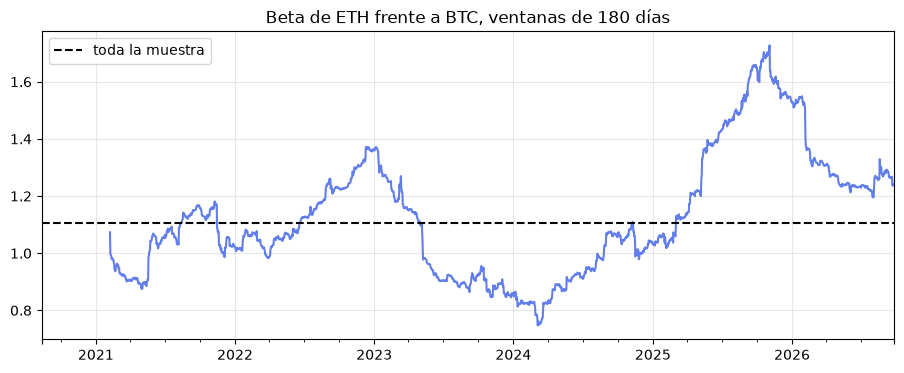

In [12]:
cov_movil = ret["ETH"].rolling(180).cov(ret["BTC"])
beta_movil = cov_movil / ret["BTC"].rolling(180).var()
ax = beta_movil.plot(title="Beta de ETH frente a BTC, ventanas de 180 días", color=COLORES["ETH"])
ax.axhline(m1.params["BTC"], color="black", linestyle="--", label="toda la muestra"); ax.legend(); ax.set_xlabel("")
plt.show()

## 6. Caso aplicado: ¿qué relaciones sirven para **anticipar**?

Que ETH y BTC se muevan juntos el mismo día no sirve para invertir: cuando lo sabes, ya pasó. La
pregunta útil es si algo de **hoy** anticipa algo de **mañana**. Dos regresiones con las mismas
variables de BTC (Unidad 3), entrenadas hasta 2024 y evaluadas en 2025-2026:

1. El **rendimiento** de mañana.
2. La **volatilidad** de los próximos 7 días.

In [13]:
d = pd.DataFrame({"r": np.log(btc["close"]).diff()})
d["r_1"] = d["r"].shift(1)
d["vol_30"] = d["r"].rolling(30).std() * np.sqrt(ANUAL)
d["vol_ewma"] = np.sqrt((d["r"] ** 2).ewm(alpha=0.06, adjust=False).mean() * ANUAL)
d["r_manana"] = d["r"].shift(-1)
d["vol_7"] = d["r"].rolling(7).std().shift(-7) * np.sqrt(ANUAL)
d = d.dropna()
e, p = d[d.index < "2025-01-01"], d[d.index >= "2025-01-01"]

filas = {}
for objetivo in ["r_manana", "vol_7"]:
    m = smf.ols(f"{objetivo} ~ r + r_1 + vol_30 + vol_ewma", data=e).fit(cov_type="HC1")
    filas[objetivo] = {"R² entrenamiento": m.rsquared,
                       "R² fuera de la muestra": r2_fuera(p[objetivo], m.predict(p), e[objetivo].mean())}
pd.DataFrame(filas).T.round(4)

,R² entrenamiento,R² fuera de la muestra
r_manana,0.0014,0.0003
vol_7,0.2366,0.3906


- **Rendimiento de mañana**: el R² es prácticamente cero dentro y fuera de la muestra: el modelo no
  mejora en nada a decir siempre "la media". La dirección no se deja anticipar.
- **Volatilidad de la semana próxima**: se anticipa una cuarta parte de su variación en entrenamiento
  y más de un tercio en 2025-2026.

Es la misma conclusión de la tesis que sostiene al piloto: no intenta adivinar si el precio sube; mide
cuánto se va a mover y ajusta cuánto tienes en cripto.

## 7. Así lo usa el piloto: cuánto riesgo aporta cada moneda

El riesgo de una cartera no es la suma del de sus monedas: depende de cuánto se mueven **juntas**. El
piloto reparte la varianza de la cartera entre las monedas con la matriz de covarianzas $\Sigma$:

$$\text{peso en riesgo}_i = \frac{w_i\,(\Sigma w)_i}{w^\top \Sigma\, w} = w_i \times \beta_i$$

donde $\beta_i$ es la **beta de la moneda frente a tu cartera**: la pendiente de la regresión del
rendimiento de la moneda sobre el de la cartera. Una moneda con β > 1 aporta más riesgo que dinero.

Con la cartera de ejemplo (0,05 BTC, 1,2 ETH, 10 SOL y 500 USDT) y los cierres del 26-09-2026. El piloto
usa covarianzas EWMA (λ = 0,94, como la volatilidad); aquí, primero, las betas por regresión del último
año, y después la cuenta exacta del piloto.

In [14]:
unidades = pd.Series({"BTC": 0.05, "ETH": 1.2, "SOL": 10.0})
usdt = 500.0
valor = unidades * precios.iloc[-1]
total = valor.sum() + usdt
w = valor / total                                   # peso en dinero (el resto, en USDT)

ultimo_ano = ret.iloc[-365:]
r_cartera = ultimo_ano @ w                          # rendimiento de la cartera cada día
betas = pd.Series({a: smf.ols("y ~ x", data=pd.DataFrame({"y": ultimo_ano[a], "x": r_cartera})).fit().params["x"]
                   for a in ACTIVOS})


def covarianza_ewma(lr, lam=0.94, arranque=30):
    """Como el piloto: empieza con la covarianza de los 30 primeros días y la actualiza cada día."""
    x = lr.to_numpy()
    v = np.cov(x[:arranque].T, bias=True)
    for fila in x:
        v = lam * v + (1 - lam) * np.outer(fila, fila)
    return pd.DataFrame(v, index=lr.columns, columns=lr.columns)


S = covarianza_ewma(ret)
marginal = S @ w
pd.DataFrame({"peso en dinero": w, "beta (regresión, último año)": betas,
              "peso en riesgo (regresión)": w * betas / (w * betas).sum(),
              "peso en riesgo (piloto, EWMA)": w * marginal / (w @ marginal),
              "volatilidad anual (EWMA)": np.sqrt(np.diag(S) * ANUAL)}).round(3)

,peso en dinero,"beta (regresión, último año)",peso en riesgo (regresión),"peso en riesgo (piloto, EWMA)",volatilidad anual (EWMA)
BTC,0.460,0.867,0.399,0.434,0.446
ETH,0.353,1.233,0.435,0.383,0.514
SOL,0.132,1.253,0.166,0.183,0.696


SOL es el 13 % del dinero y aporta el 18 % del riesgo, porque se mueve más que la cartera (β > 1);
BTC es el 46 % del dinero y el 43 % del riesgo. Las dos estimaciones de la beta (regresión del último
año y EWMA) no coinciden porque pesan el pasado de forma distinta: la EWMA mira sobre todo el último
mes. La última columna es la tabla **"Qué parte del riesgo aporta cada moneda"** del
piloto, con las mismas cifras que muestra para esta cartera con los cierres de ese día. (El peso en
dinero del piloto incluye los USDT en el total; por eso las tres monedas suman menos de 1.)

## Ejercicios

1. **Al revés.** Ajusta `BTC ~ ETH`. ¿La β es la inversa de la de `ETH ~ BTC`? ¿Por qué no? (Pista: el
   R² es el mismo; mira la fórmula de β = cov / var.)
2. **Rendimientos en %.** Multiplica los rendimientos por 100 y repite la regresión simple. ¿Qué cambia
   en α, β, sus errores típicos y el R²?
3. **Un año agitado.** Ajusta `ETH ~ BTC` solo con 2022 y solo con 2025. ¿Cambia la β? ¿Y el R²?
4. **Tu cartera.** Cambia las unidades en la sección 7. ¿Hay alguna combinación en la que el peso en
   riesgo de cada moneda sea igual a su peso en dinero? ¿Qué tendrían que cumplir las betas?